# Solaris Analytics

### **ADS508 | Group 7 | Authors: Luigi Salemi, Francisco Hernandez**
### This notebook covers ingestion and EDA for all primary datasets:

| # | Dataset | Source | Type |
|---|---------|--------|------|
| 1 | Houston Solar Irradiance 2000–2019 (NREL NSRDB) | S3 | CSV — irradiance + weather |
| 2 | GPVS-Faults PV Sensor Readings | S3 | CSV — electrical sensor + fault labels |
| 3 | Solar Panel Images (`pythonafroz`) | KaggleHub | Images — clean vs faulty |
| 4 | PV Panel Defect Dataset (`alicjalena`) | KaggleHub | Images — 6 defect classes |
 
 **S3 Bucket:** `s3://solaris-analytics-bucket/`  
 **GitHub:** https://github.com/darth-franky/Applied-Data-Science/tree/main/ADS508

In [34]:
import subprocess
subprocess.run(['pip', 'install', 'kagglehub', '-q'])

import os
import boto3
import sagemaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import kagglehub
from pathlib import Path

session = sagemaker.Session()
s3 = boto3.client('s3')
role = sagemaker.get_execution_role()

BUCKET = 'solaris-analytics-bucket'
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

print(f'SageMaker Role: {role}')
print(f'S3 Bucket: s3://{BUCKET}/')

SageMaker Role: arn:aws:iam::187806919439:role/LabRole
S3 Bucket: s3://solaris-analytics-bucket/


In [35]:
# List ALL objects in the bucket to find the exact key
response = s3.list_objects_v2(Bucket=BUCKET)
for obj in response.get('Contents', []):
    print(obj['Key'])

CSV_Files/F0L.csv
CSV_Files/F0M.csv
CSV_Files/F1L.csv
CSV_Files/F1M.csv
CSV_Files/F2L.csv
CSV_Files/F2M.csv
CSV_Files/F3L.csv
CSV_Files/F3M.csv
CSV_Files/F4L.csv
CSV_Files/F4M.csv
CSV_Files/F5L.csv
CSV_Files/F5M.csv
CSV_Files/F6L.csv
CSV_Files/F6M.csv
CSV_Files/F7L.csv
CSV_Files/F7M.csv
F0L.mat
F0M.mat
F1L.mat
F1M.mat
F2L.mat
F2M.mat
F3L.mat
F3M.mat
F4L.mat
F4M.mat
F5L.mat
F5M.mat
F6L.mat
F6M.mat
F7L.mat
F7M.mat
Houston_Solar_2000_2019.csv
ReadMe.pdf
panel-images/pv-defect/test/Bird-drop/Bird (137).JPG
panel-images/pv-defect/test/Bird-drop/Bird (14).JPG
panel-images/pv-defect/test/Bird-drop/Bird (140).jpg
panel-images/pv-defect/test/Bird-drop/Bird (146).jpg
panel-images/pv-defect/test/Bird-drop/Bird (148).jpg
panel-images/pv-defect/test/Bird-drop/Bird (16).JPG
panel-images/pv-defect/test/Bird-drop/Bird (164).jpg
panel-images/pv-defect/test/Bird-drop/Bird (196).jpg
panel-images/pv-defect/test/Bird-drop/Bird (211).JPG
panel-images/pv-defect/test/Bird-drop/Bird (33).jpg
panel-images/pv-de

## 1. Ingest Houston Solar Irradiance Dataset (NREL NSRDB) from S3

**File:** `Houston_Solar_2000_2019.csv`  
**S3 path:** `s3://solaris-analytics-bucket/Houston_Solar_2000_2019.csv`  
**Key fields:** `Timestamp`, `GHI`, `DNI`, `DHI`, `Temperature`, `Wind_Speed`  
**Records:** ~350,000 rows at 30-min intervals (2000-2019)

In [36]:
import os

# Create folder
os.makedirs('/home/sagemaker-user/dataset1', exist_ok=True)

# Set paths
nsrdb_s3_key = 'Houston_Solar_2000_2019.csv'
nsrdb_local  = '/home/sagemaker-user/dataset1/Houston_Solar_2000_2019.csv'

# Download from S3
print(f'Downloading s3://{BUCKET}/{nsrdb_s3_key} ...')
s3.download_file(BUCKET, nsrdb_s3_key, nsrdb_local)
print('Download complete.')

# Load into DataFrame
nsrdb_df = pd.read_csv(nsrdb_local, parse_dates=['Timestamp'])
print(f'Shape: {nsrdb_df.shape}')
nsrdb_df.head()

Download complete.
Shape: (350640, 6)


,Timestamp,GHI,DNI,DHI,Temperature,Wind_Speed
0,2000-01-01 00:00:00,0,0,0,11.9,0.7
1,2000-01-01 00:30:00,0,0,0,11.5,0.7
2,2000-01-01 01:00:00,0,0,0,11.1,0.8
3,2000-01-01 01:30:00,0,0,0,10.6,0.9
4,2000-01-01 02:00:00,0,0,0,10.1,1.0


### 1.1 NSRDB — Basic Info & Missing Values

In [37]:
print('=== Data Types ===')
print(nsrdb_df.dtypes)

print('\n=== Missing Values ===')
missing = nsrdb_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

print('\n=== Descriptive Statistics ===')
display(nsrdb_df.describe().T)

=== Data Types ===
Timestamp      datetime64[ns]
GHI                     int64
DNI                     int64
DHI                     int64
Temperature           float64
Wind_Speed            float64
dtype: object

=== Missing Values ===
No missing values found.

=== Descriptive Statistics ===


,count,mean,min,25%,50%,75%,max,std
Timestamp,350640,2009-12-31 11:45:00.000001024,2000-01-01 00:00:00,2004-12-31 05:52:30,2009-12-31 11:45:00,2014-12-31 17:37:30,2019-12-31 23:30:00,NaN
GHI,350640.0,201.67449,0.0,0.0,0.0,365.0,1078.0,287.283358
DNI,350640.0,197.567154,0.0,0.0,0.0,348.0,1045.0,313.197351
DHI,350640.0,79.42834,0.0,0.0,0.0,120.0,663.0,116.628882
Temperature,350640.0,20.82322,-7.0,15.2,22.2,26.6,43.6,8.2369
Wind_Speed,350640.0,2.218328,0.2,1.3,2.0,2.9,10.7,1.128439


### 1.2 NSRDB — Irradiance & Weather Distributions

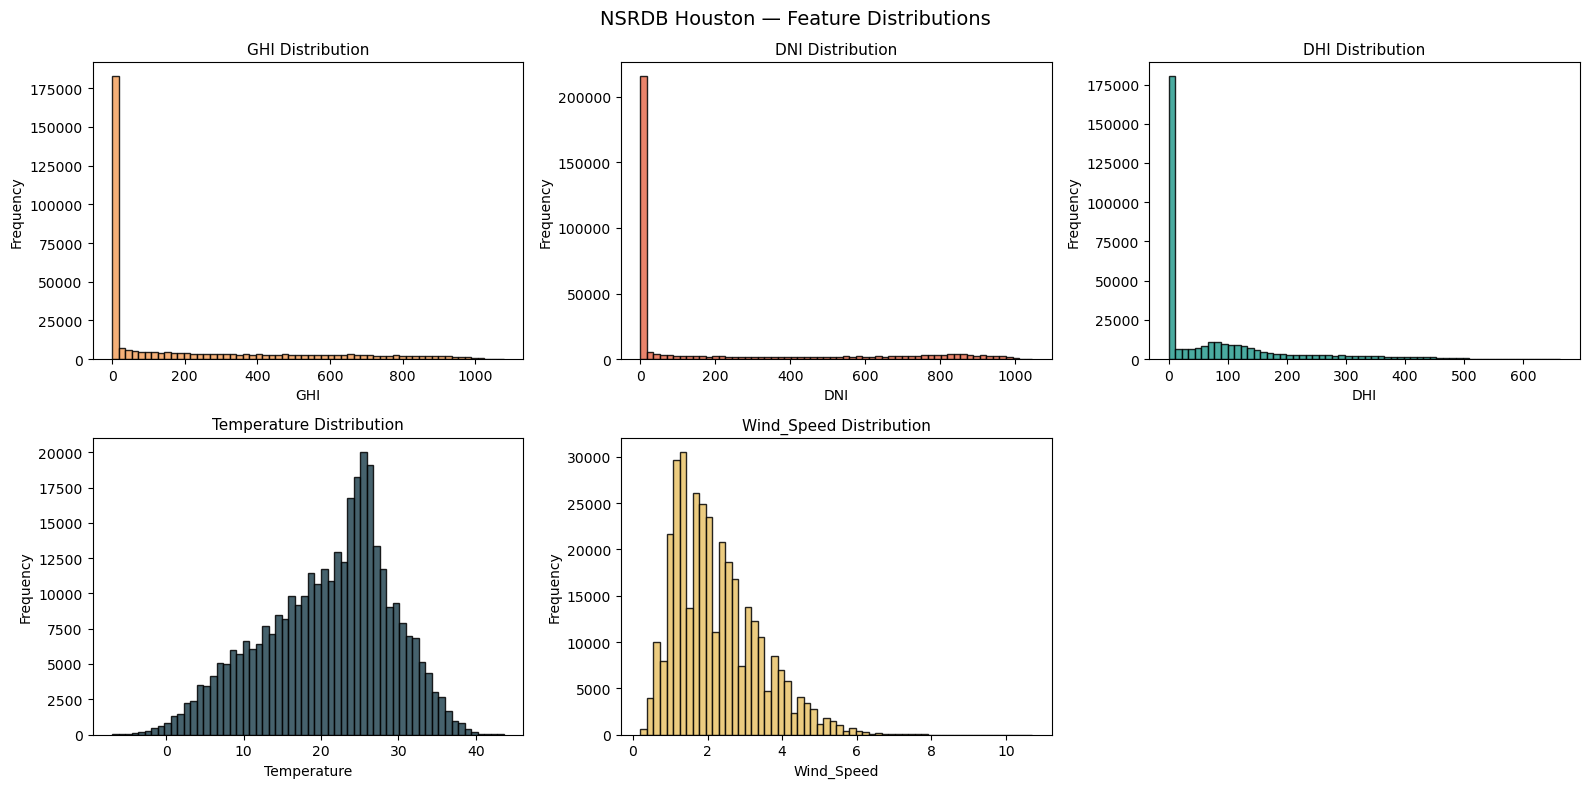

Note: High frequency of GHI=0 reflects nighttime — these rows may be filtered before forecasting.


In [38]:
irradiance_cols = ['GHI', 'DNI', 'DHI']
weather_cols    = ['Temperature', 'Wind_Speed']
all_numeric     = irradiance_cols + weather_cols

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = ['#F4A261', '#E76F51', '#2A9D8F', '#264653', '#E9C46A']

for i, col in enumerate(all_numeric):
    axes[i].hist(nsrdb_df[col].dropna(), bins=60, color=colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
plt.suptitle('NSRDB Houston — Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/nsrdb_distributions.png', dpi=150)
plt.show()
print('Note: High frequency of GHI=0 reflects nighttime — these rows may be filtered before forecasting.')

### 1.3 NSRDB — Seasonal & Temporal Bias Check

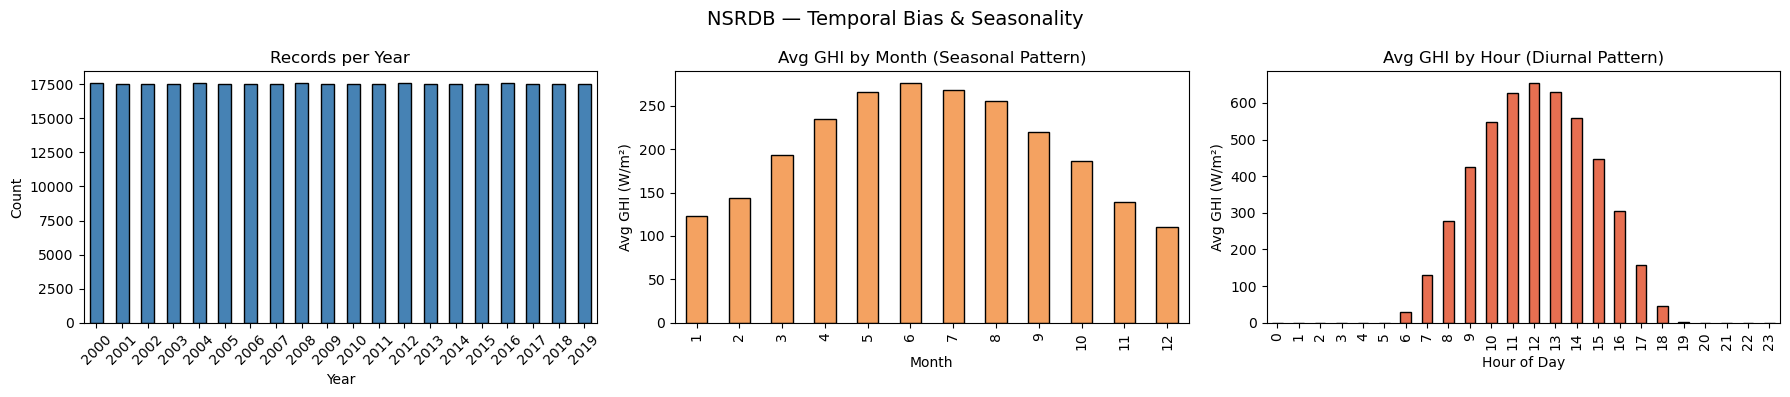

Note: NSRDB is U.S.-centric (Houston only). Seasonal and diurnal patterns are expected physical behavior.


In [39]:
nsrdb_df['Year']  = nsrdb_df['Timestamp'].dt.year
nsrdb_df['Month'] = nsrdb_df['Timestamp'].dt.month
nsrdb_df['Hour']  = nsrdb_df['Timestamp'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

nsrdb_df['Year'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Records per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

nsrdb_df.groupby('Month')['GHI'].mean().plot(
    kind='bar', ax=axes[1], color='#F4A261', edgecolor='black')
axes[1].set_title('Avg GHI by Month (Seasonal Pattern)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg GHI (W/m²)')

nsrdb_df.groupby('Hour')['GHI'].mean().plot(
    kind='bar', ax=axes[2], color='#E76F51', edgecolor='black')
axes[2].set_title('Avg GHI by Hour (Diurnal Pattern)')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg GHI (W/m²)')

plt.suptitle('NSRDB — Temporal Bias & Seasonality', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/nsrdb_temporal_bias.png', dpi=150)
plt.show()
print('Note: NSRDB is U.S.-centric (Houston only). Seasonal and diurnal patterns are expected physical behavior.')

### 1.4 NSRDB — GHI Irradiance Category Distribution
Per the design doc, GHI will be bucketed into **Low / Medium / High** for classification tasks.

=== GHI Category Distribution (daytime only) ===
GHI_Category
Medium    67793
Low       57143
High      50195
Name: count, dtype: int64


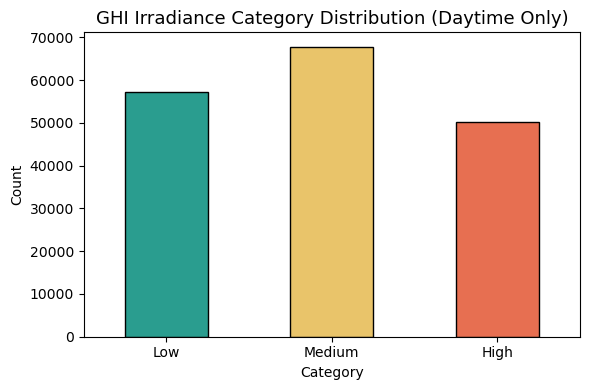

In [40]:
daytime_df = nsrdb_df[nsrdb_df['GHI'] > 0].copy()
daytime_df['GHI_Category'] = pd.cut(
    daytime_df['GHI'],
    bins=[0, 200, 600, daytime_df['GHI'].max() + 1],
    labels=['Low', 'Medium', 'High']
)

print('=== GHI Category Distribution (daytime only) ===')
print(daytime_df['GHI_Category'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
daytime_df['GHI_Category'].value_counts().reindex(['Low','Medium','High']).plot(
    kind='bar', ax=ax, color=['#2A9D8F','#E9C46A','#E76F51'], edgecolor='black'
)
ax.set_title('GHI Irradiance Category Distribution (Daytime Only)', fontsize=13)
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('/tmp/nsrdb_ghi_categories.png', dpi=150)
plt.show()

### 1.5 NSRDB — Correlation Heatmap

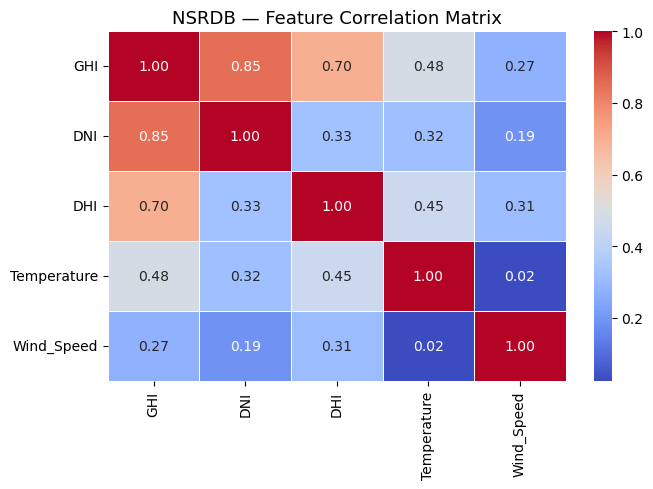

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(nsrdb_df[all_numeric].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('NSRDB — Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/tmp/nsrdb_correlation.png', dpi=150)
plt.show()

## 2. Ingest GPVS-Faults Sensor Dataset from S3

**S3 path:** `s3://solaris-analytics-bucket/dataset2/gpvs-faults/`  
**Key fields:** voltage, current, power, fault_label  
**Records:** 10,000+

In [42]:
response  = s3.list_objects_v2(Bucket=BUCKET)
gpvs_keys = [obj['Key'] for obj in response.get('Contents', [])]

local_gpvs_dir = '/home/sagemaker-user/dataset2/gpvs-faults/'
os.makedirs(local_gpvs_dir, exist_ok=True)

for key in gpvs_keys:
    filename = key.split('/')[-1]
    if filename:
        local_path = os.path.join(local_gpvs_dir, filename)
        s3.download_file(BUCKET, key, local_path)
        print(f'Downloaded: {key}')

csv_files = list(Path(local_gpvs_dir).glob('*.csv')) + list(Path(local_gpvs_dir).glob('*.tsv'))
dfs = []
for f in csv_files:
    sep = '\t' if f.suffix == '.tsv' else ','
    df_temp = pd.read_csv(f, sep=sep)
    df_temp['source_file'] = f.name
    dfs.append(df_temp)
    print(f'Loaded {f.name}: {df_temp.shape}')

gpvs_df = pd.concat(dfs, ignore_index=True)
print(f'\nCombined GPVS shape: {gpvs_df.shape}')
gpvs_df.head()

Downloaded: CSV_Files/F0L.csv
Downloaded: CSV_Files/F0M.csv
Downloaded: CSV_Files/F1L.csv
Downloaded: CSV_Files/F1M.csv
Downloaded: CSV_Files/F2L.csv
Downloaded: CSV_Files/F2M.csv
Downloaded: CSV_Files/F3L.csv
Downloaded: CSV_Files/F3M.csv
Downloaded: CSV_Files/F4L.csv
Downloaded: CSV_Files/F4M.csv
Downloaded: CSV_Files/F5L.csv
Downloaded: CSV_Files/F5M.csv
Downloaded: CSV_Files/F6L.csv
Downloaded: CSV_Files/F6M.csv
Downloaded: CSV_Files/F7L.csv
Downloaded: CSV_Files/F7M.csv
Downloaded: F0L.mat
Downloaded: F0M.mat
Downloaded: F1L.mat
Downloaded: F1M.mat
Downloaded: F2L.mat
Downloaded: F2M.mat
Downloaded: F3L.mat
Downloaded: F3M.mat
Downloaded: F4L.mat
Downloaded: F4M.mat
Downloaded: F5L.mat
Downloaded: F5M.mat
Downloaded: F6L.mat
Downloaded: F6M.mat
Downloaded: F7L.mat
Downloaded: F7M.mat
Downloaded: Houston_Solar_2000_2019.csv
Downloaded: ReadMe.pdf
Downloaded: panel-images/pv-defect/test/Bird-drop/Bird (137).JPG
Downloaded: panel-images/pv-defect/test/Bird-drop/Bird (14).JPG
Download

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,...,If,Vabc,Vf,source_file,Timestamp,GHI,DNI,DHI,Temperature,Wind_Speed
0,0.000028,1.572327,101.348877,144.140625,-0.135133,0.490112,-0.354985,41.744537,-149.872894,109.064585,...,50.0,1.0,50.0,F0L.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000128,1.503265,101.458740,143.554688,-0.108277,0.510254,-0.388555,46.831512,-150.716705,105.829976,...,50.0,1.0,50.0,F0L.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000228,1.492859,101.574707,143.554688,-0.168702,0.496826,-0.334844,51.074677,-152.018585,102.543132,...,50.0,1.0,50.0,F0L.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000328,1.558136,101.312256,143.261719,-0.135133,0.510254,-0.361699,55.848236,-152.585144,98.143260,...,50.0,1.0,50.0,F0L.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000428,1.631927,101.141357,143.847656,-0.202271,0.503540,-0.321416,60.055237,-152.609253,94.261729,...,50.0,1.0,50.0,F0L.csv,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 GPVS — Basic Info, Missing Values & Zero-Value Check

In [43]:
print('=== Data Types ===')
print(gpvs_df.dtypes)

print('\n=== Missing Values ===')
missing = gpvs_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

numeric_cols = gpvs_df.select_dtypes(include=[np.number]).columns.tolist()

print('\n=== Zero-Value Counts (potential sensor outage indicator) ===')
zero_counts = (gpvs_df[numeric_cols] == 0).sum()
zero_pct    = (zero_counts / len(gpvs_df) * 100).round(2)
print(pd.DataFrame({'Zero Count': zero_counts, 'Zero %': zero_pct}).to_string())
print('\nNote: High zero % in voltage/current/power may indicate sensor outages needing removal in data prep.')

=== Data Types ===
Time           float64
Ipv            float64
Vpv            float64
Vdc            float64
ia             float64
ib             float64
ic             float64
va             float64
vb             float64
vc             float64
Iabc           float64
If             float64
Vabc           float64
Vf             float64
source_file     object
Timestamp       object
GHI            float64
DNI            float64
DHI            float64
Temperature    float64
Wind_Speed     float64
dtype: object

=== Missing Values ===
Time            350640
Ipv             350640
Vpv             350640
Vdc             350640
ia              350640
ib              350640
ic              350640
va              350640
vb              350640
vc              350640
Iabc            350640
If              350640
Vabc            350640
Vf              350640
Timestamp      2163480
GHI            2163480
DNI            2163480
DHI            2163480
Temperature    2163480
Wind_Speed     2163480


### 2.2 GPVS — Feature Distributions & Correlation

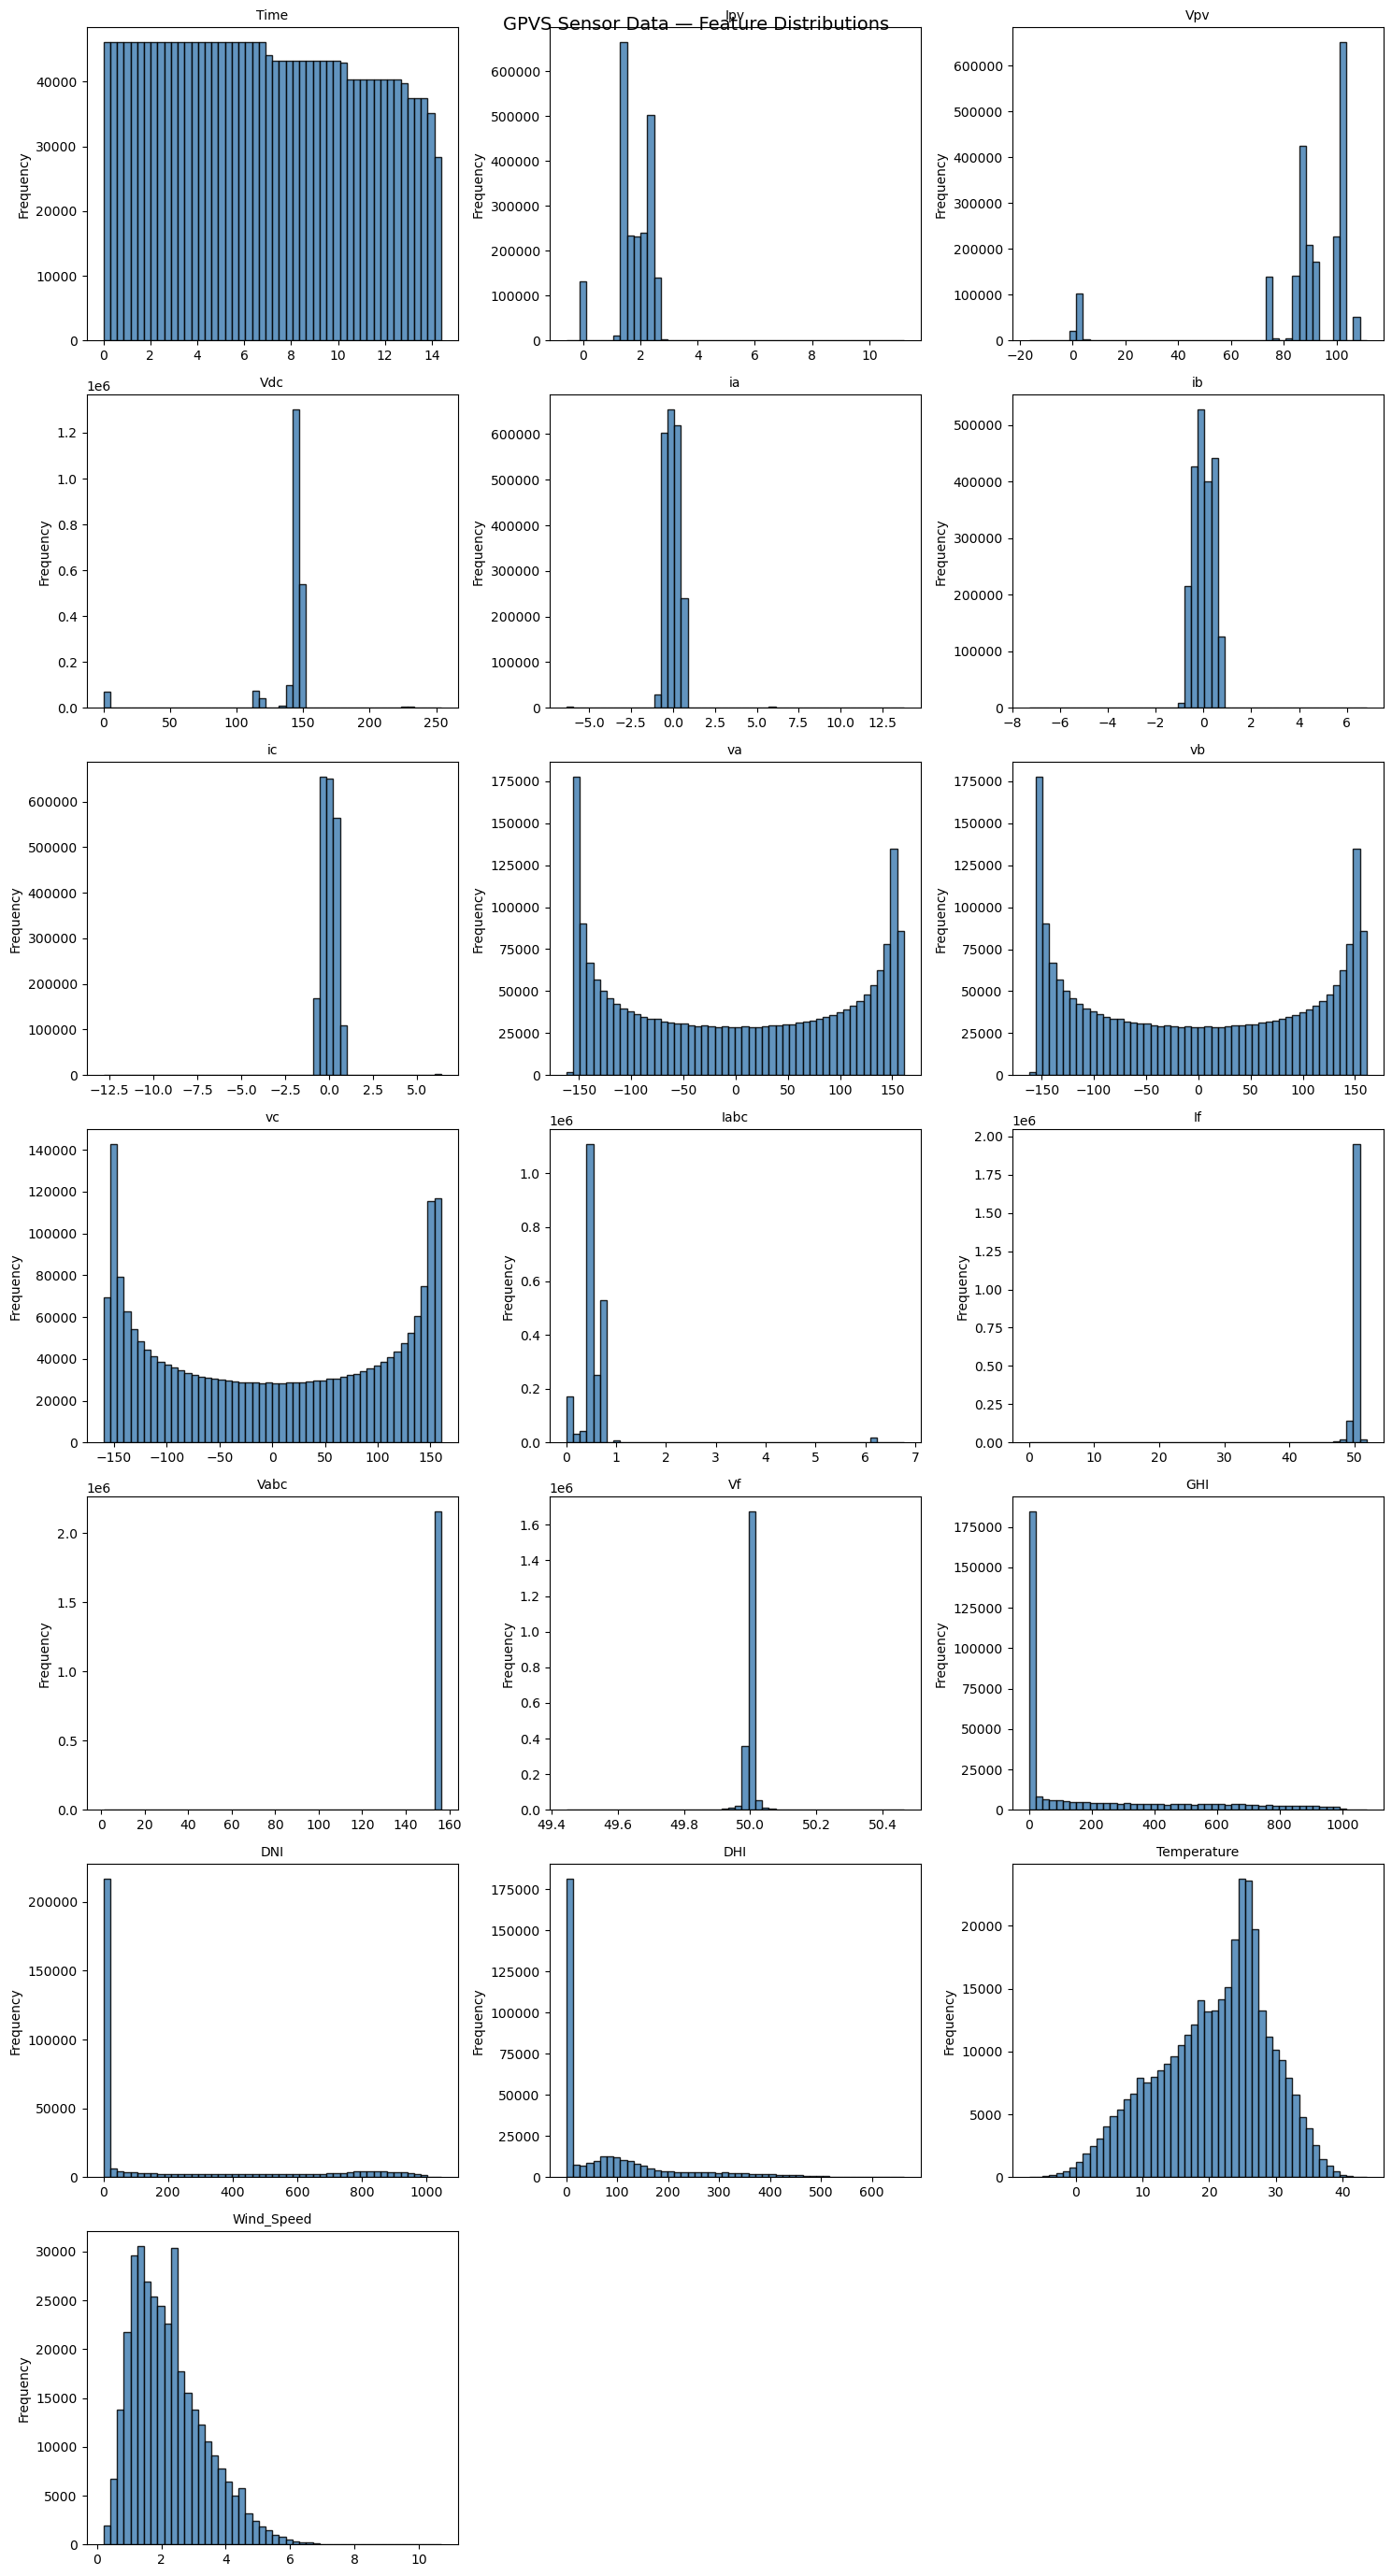

In [44]:
plot_cols = [c for c in numeric_cols if c not in (fault_col_candidates or [])]
n = len(plot_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(gpvs_df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GPVS Sensor Data — Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/gpvs_distributions.png', dpi=150)
plt.show()

---
## 3. Ingest Image Datasets via KaggleHub → Upload to S3

Two image datasets downloaded from Kaggle and persisted to S3:
- **`pythonafroz/solar-panel-images`** → binary: clean vs faulty panels
- **`alicjalena/pv-panel-defect-dataset`** → multi-class: 6 defect types

In [45]:
def upload_dir_to_s3(local_dir, s3_prefix, bucket):
    """Recursively upload a local directory to an S3 prefix."""
    count = 0
    for root, _, files in os.walk(local_dir):
        for file in files:
            local_path = os.path.join(root, file)
            rel_path   = os.path.relpath(local_path, local_dir)
            s3_key     = s3_prefix + rel_path.replace(os.sep, '/')
            s3.upload_file(local_path, bucket, s3_key)
            count += 1
    return count

def count_images_by_class(base_path):
    """Return dict of {class_name: image_count} from a folder of class subfolders."""
    counts = {}
    for item in Path(base_path).iterdir():
        if item.is_dir():
            n = sum(1 for f in item.rglob('*') if f.suffix.lower() in IMAGE_EXTENSIONS)
            if n > 0:
                counts[item.name] = n
    return counts

print('Helper functions defined.')

Helper functions defined.


In [46]:
# Download Solar Panel Images (pythonafroz)
print('Downloading pythonafroz/solar-panel-images ...')
solar_panel_path = kagglehub.dataset_download('pythonafroz/solar-panel-images')
print(f'Downloaded to: {solar_panel_path}')

n = upload_dir_to_s3(solar_panel_path, 'panel-images/solar-panel-images/', BUCKET)
print(f'Uploaded {n} files to s3://{BUCKET}/panel-images/solar-panel-images/')

Downloaded to: /home/sagemaker-user/.cache/kagglehub/datasets/pythonafroz/solar-panel-images/versions/2
Uploaded 891 files to s3://solaris-analytics-bucket/panel-images/solar-panel-images/


In [47]:
# Download PV Panel Defect Dataset (alicjalena)
print('Downloading alicjalena/pv-panel-defect-dataset ...')
pv_defect_path = kagglehub.dataset_download('alicjalena/pv-panel-defect-dataset')
print(f'Downloaded to: {pv_defect_path}')

n = upload_dir_to_s3(pv_defect_path, 'panel-images/pv-defect/', BUCKET)
print(f'Uploaded {n} files to s3://{BUCKET}/panel-images/pv-defect/')

Downloaded to: /home/sagemaker-user/.cache/kagglehub/datasets/alicjalena/pv-panel-defect-dataset/versions/1
Uploaded 1574 files to s3://solaris-analytics-bucket/panel-images/pv-defect/


### 3.1 Solar Panel Images (pythonafroz) — Distribution & Samples

=== Solar Panel Images — Images per Class ===
  Faulty_solar_panel: 885 images
Total: 885


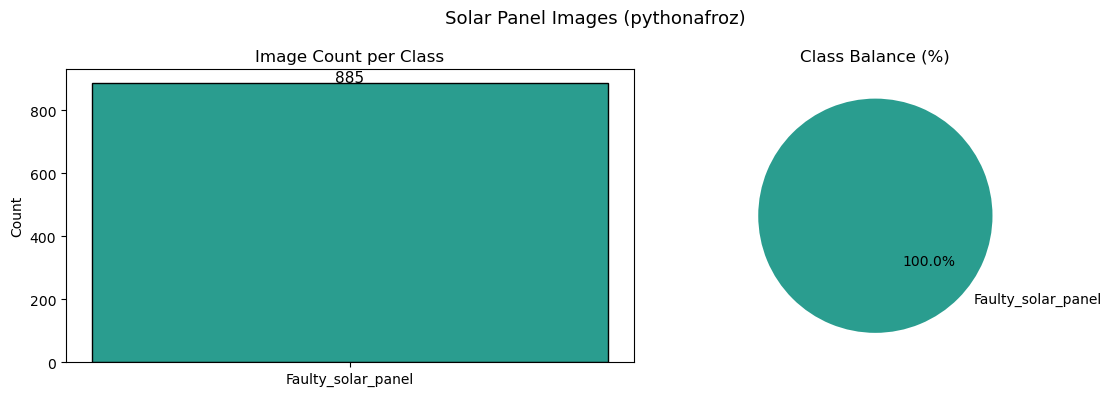

In [48]:
solar_counts = count_images_by_class(solar_panel_path)
print('=== Solar Panel Images — Images per Class ===')
for cls, cnt in sorted(solar_counts.items()):
    print(f'  {cls}: {cnt} images')
print(f'Total: {sum(solar_counts.values())}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(solar_counts.keys(), solar_counts.values(), color=['#2A9D8F','#E76F51'], edgecolor='black')
for i, (cls, cnt) in enumerate(solar_counts.items()):
    axes[0].text(i, cnt + 5, str(cnt), ha='center', fontsize=11)
axes[0].set_title('Image Count per Class', fontsize=12)
axes[0].set_ylabel('Count')

axes[1].pie(solar_counts.values(), labels=solar_counts.keys(),
            autopct='%1.1f%%', colors=['#2A9D8F','#E76F51'], startangle=140)
axes[1].set_title('Class Balance (%)', fontsize=12)

plt.suptitle('Solar Panel Images (pythonafroz)', fontsize=13)
plt.tight_layout()
plt.savefig('/tmp/solar_panel_distribution.png', dpi=150)
plt.show()

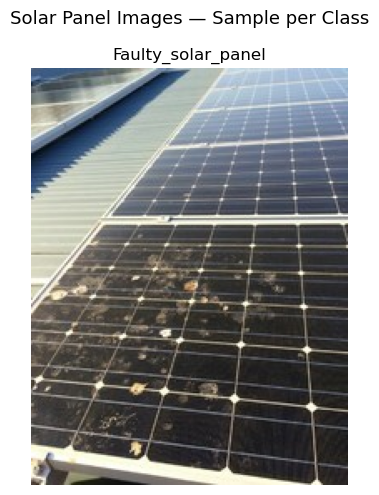

In [49]:
# Sample one image per class
classes = sorted(solar_counts.keys())
fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5))
if len(classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, classes):
    class_dir = Path(solar_panel_path) / cls
    imgs = [f for f in class_dir.rglob('*') if f.suffix.lower() in IMAGE_EXTENSIONS]
    if imgs:
        ax.imshow(mpimg.imread(str(imgs[0])))
        ax.set_title(cls, fontsize=12)
        ax.axis('off')

plt.suptitle('Solar Panel Images — Sample per Class', fontsize=13)
plt.tight_layout()
plt.savefig('/tmp/solar_panel_samples.png', dpi=150)
plt.show()

### 3.2 PV Panel Defect Dataset (alicjalena) — Distribution & Samples

=== PV Panel Defect Dataset — Images per Class ===
  test: 95 images
  train: 929 images
  val: 550 images
Total: 1574


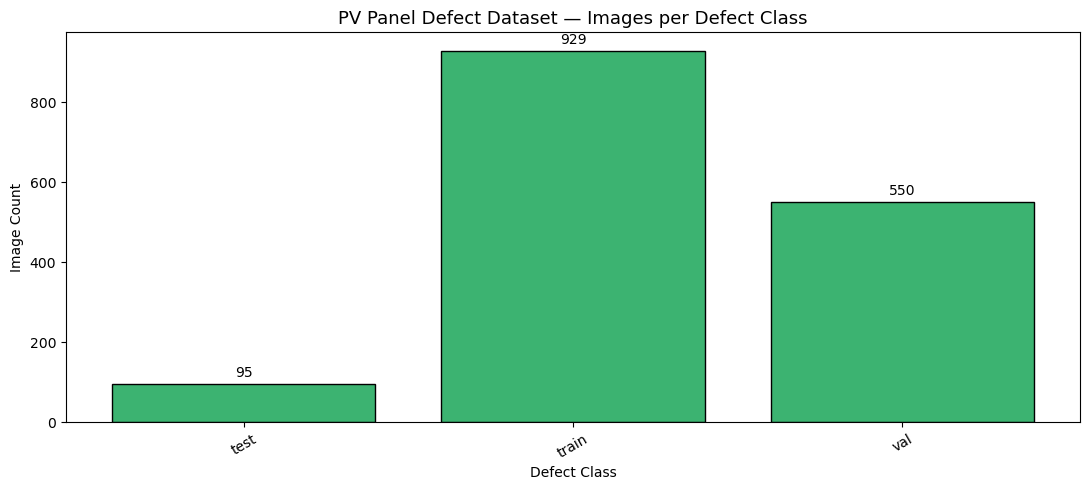

Note: Underrepresented defect classes will require augmentation or class weighting during CNN training.


In [50]:
defect_counts = count_images_by_class(pv_defect_path)
print('=== PV Panel Defect Dataset — Images per Class ===')
for cls, cnt in sorted(defect_counts.items()):
    print(f'  {cls}: {cnt} images')
print(f'Total: {sum(defect_counts.values())}')

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(defect_counts.keys(), defect_counts.values(), color='mediumseagreen', edgecolor='black')
ax.bar_label(bars, padding=3)
ax.set_title('PV Panel Defect Dataset — Images per Defect Class', fontsize=13)
ax.set_xlabel('Defect Class')
ax.set_ylabel('Image Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('/tmp/pv_defect_distribution.png', dpi=150)
plt.show()
print('Note: Underrepresented defect classes will require augmentation or class weighting during CNN training.')

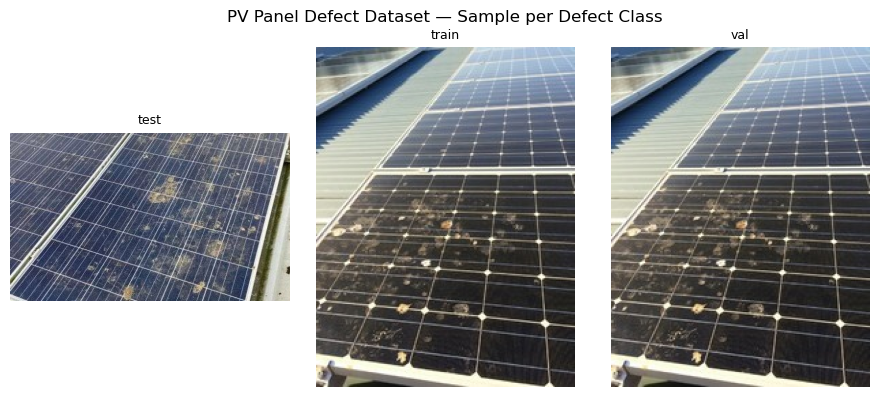

In [51]:
display_classes = sorted(defect_counts.keys())[:6]
fig, axes = plt.subplots(1, len(display_classes), figsize=(3 * len(display_classes), 4))
if len(display_classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, display_classes):
    class_dir = Path(pv_defect_path) / cls
    imgs = [f for f in class_dir.rglob('*') if f.suffix.lower() in IMAGE_EXTENSIONS]
    if imgs:
        ax.imshow(mpimg.imread(str(imgs[0])))
        ax.set_title(cls, fontsize=9)
        ax.axis('off')

plt.suptitle('PV Panel Defect Dataset — Sample per Defect Class', fontsize=12)
plt.tight_layout()
plt.savefig('/tmp/pv_defect_samples.png', dpi=150)
plt.show()

---
## 4. Full EDA Summary

In [52]:
print('=' * 62)
print('       SOLARIS ANALYTICS — COMPLETE EDA SUMMARY')
print('=' * 62)

print(f'\n[1] NSRDB Houston Solar Irradiance (2000-2019)')
print(f'    Rows:       {len(nsrdb_df):,}')
print(f'    Columns:    {nsrdb_df.shape[1]}')
print(f'    Date Range: {nsrdb_df["Timestamp"].min()} to {nsrdb_df["Timestamp"].max()}')
print(f'    Missing:    {nsrdb_df.isnull().sum().sum()}')
print(f'    GHI Range:  {nsrdb_df["GHI"].min()} - {nsrdb_df["GHI"].max()} W/m2')
print(f'    Key Risk:   U.S.-centric (Houston only); seasonal/diurnal bias expected')

print(f'\n[2] GPVS-Faults Sensor Data')
print(f'    Rows:       {len(gpvs_df):,}')
print(f'    Columns:    {gpvs_df.shape[1]}')
print(f'    Missing:    {gpvs_df.isnull().sum().sum()}')
print(f'    Key Risk:   Single PV system source; check fault class imbalance')

print(f'\n[3] Solar Panel Images (pythonafroz) — Binary Classification')
for cls, cnt in sorted(solar_counts.items()):
    print(f'    {cls}: {cnt} images')
print(f'    Total: {sum(solar_counts.values())} | Key Risk: Binary class balance')

print(f'\n[4] PV Panel Defect Dataset (alicjalena) — Multi-class (6 classes)')
for cls, cnt in sorted(defect_counts.items()):
    print(f'    {cls}: {cnt} images')
print(f'    Total: {sum(defect_counts.values())} | Key Risk: Multi-class imbalance')

print(f'\nAll data stored at: s3://{BUCKET}/')
print(f'  nsrdb/                          <- NREL irradiance CSV')
print(f'  gpvs-faults/                    <- PV sensor fault CSV')
print(f'  panel-images/solar-panel-images/ <- pythonafroz images')
print(f'  panel-images/pv-defect/          <- alicjalena images')
print(f'\nGitHub: https://github.com/darth-franky/Applied-Data-Science/tree/main/ADS508')
print('=' * 62)

       SOLARIS ANALYTICS — COMPLETE EDA SUMMARY

[1] NSRDB Houston Solar Irradiance (2000-2019)
    Rows:       350,640
    Columns:    9
    Date Range: 2000-01-01 00:00:00 to 2019-12-31 23:30:00
    Missing:    0
    GHI Range:  0 - 1078 W/m2
    Key Risk:   U.S.-centric (Houston only); seasonal/diurnal bias expected

[2] GPVS-Faults Sensor Data
    Rows:       2,514,120
    Columns:    21
    Missing:    17889840
    Key Risk:   Single PV system source; check fault class imbalance

[3] Solar Panel Images (pythonafroz) — Binary Classification
    Faulty_solar_panel: 885 images
    Total: 885 | Key Risk: Binary class balance

[4] PV Panel Defect Dataset (alicjalena) — Multi-class (6 classes)
    test: 95 images
    train: 929 images
    val: 550 images
    Total: 1574 | Key Risk: Multi-class imbalance

All data stored at: s3://solaris-analytics-bucket/
  nsrdb/                          <- NREL irradiance CSV
  gpvs-faults/                    <- PV sensor fault CSV
  panel-images/solar